In [11]:
import csv
import nibabel as nib
import matplotlib.pyplot as plt
import random
import torch
import os
import numpy as np
from model1 import CNN_3D,NiiDataset,MultiModalTransformer,NeuralNet,TransEModel,KGMultiModalTransformer
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import nibabel as nib
import shutil
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import math
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import pandas as pd

In [12]:
path_existence = []
data_prodromal=[]
data_swedd=[]
data_control=[]
data_PD = []
count_control = 0
count_PD = 0
count_swedd = 0
count_prodromal = 0
with open('PD1.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader)  
    for row in csv_reader:
        path = 'PD/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_PD=count_PD+1
            data_PD.append(row)
            
with open('control.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'Control/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_control=count_control+1
            data_control.append(row)
            
with open('swedd.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'SWEDD/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_swedd=count_swedd+1
            data_swedd.append(row)

with open('prodromal.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'Prodromal/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_prodromal=count_prodromal+1
            data_prodromal.append(row)
print(count_PD) #125
print(count_control) #132
print(count_swedd) #72
print(count_prodromal)#80

125
132
72
80


In [13]:
PD_arrays=[]
replace_dict = {'F': '0','M':'1','Normal':'0','Slight':'1','Mild':'2','Moderate':'3','Severe':'4','T1-anatomical':'1','Processed':'1', 
               'BL':'0','V04':'1','V06':'2','V06':'3','V08':'4','V10':'5','NiFTI':'1','':'0','No':'0','Yes':'1','Stage 1':'1','Stage 2':'2','Stage 3':'3','Stage 4':'4'
               ,'On':'1','Off':'0','Stage 0':'0'}
for i in data_PD:
    j= i[21:]
    j= [replace_dict.get(item, item) for item in j]
    num_list = [float(num) for num in j]
    PD_array = np.array(num_list)
    PD_arrays.append(PD_array)
PD_array = np.vstack(PD_arrays)

control_arrays = []
for i in data_control:
    j = i[21:]
    j = [replace_dict.get(item, item) for item in j]
    num_list = [float(num) for num in j]
    control_array = np.array(num_list)
    control_arrays.append(control_array)
control_array = np.vstack(control_arrays)

swedd_arrays = []
for i in data_swedd:
    j = i[21:]
    j = [replace_dict.get(item, item) for item in j]
    num_list = [float(num) for num in j]
    swedd_array = np.array(num_list)
    swedd_arrays.append(swedd_array)
swedd_array = np.vstack(swedd_arrays)

prodromal_arrays = []
for i in data_prodromal:
    j = i[21:]
    j = [replace_dict.get(item, item) for item in j]
    num_list = [float(num) for num in j]
    prodromal_array = np.array(num_list)
    prodromal_arrays.append(prodromal_array)
prodromal_array = np.vstack(prodromal_arrays)

#加权算值
def weighted_sum(tensor):
    weights = [0.1, 0.3, 0.5 , 0.7]
    weight_tensor = torch.tensor(weights, dtype=tensor.dtype, device=tensor.device)
    weighted_sum_result = torch.sum(tensor * weight_tensor, dim=1, keepdim=True)
    return weighted_sum_result

In [14]:
pd_tensor = torch.from_numpy(PD_array).float()
control_tensor = torch.from_numpy(control_array).float()
swedd_tensor = torch.from_numpy(swedd_array).float()
prodromal_tensor = torch.from_numpy(prodromal_array).float()

pd_labels = torch.zeros(pd_tensor.shape[0], dtype=torch.long)
control_labels = torch.ones(control_tensor.shape[0], dtype=torch.long)
swedd_labels = torch.full((swedd_tensor.shape[0],), 3, dtype=torch.long)
prodromal_labels = torch.full((prodromal_tensor.shape[0],), 2, dtype=torch.long)

X = torch.cat([pd_tensor, control_tensor, swedd_tensor,prodromal_tensor], dim=0)
y = torch.cat([pd_labels , control_labels  ,swedd_labels, prodromal_labels], dim=0)

dataset = TensorDataset(X, y)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)
model = NeuralNet(embedding=64)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 50
for epoch in range(num_epochs):
    for inputs, labels in dataloader:
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')
        
with torch.no_grad():
    pd_tensor = model(pd_tensor)
    control_tensor = model(control_tensor)
    swedd_tensor = model(swedd_tensor)
    prodromal_tensor = model(prodromal_tensor)
    
pd_tensor = weighted_sum(pd_tensor)
control_tensor = weighted_sum(control_tensor)
swedd_tensor = weighted_sum(swedd_tensor)
prodromal_tensor = weighted_sum(prodromal_tensor)

Epoch [10/50], Loss: 0.7221
Epoch [20/50], Loss: 0.5481
Epoch [30/50], Loss: 0.5070
Epoch [40/50], Loss: 0.2653
Epoch [50/50], Loss: 0.3887


In [15]:
# 数据处理函数
def preprocess_data(data, replace_dict):
    processed_data = []
    for row in data:
        row = [replace_dict.get(item, item) for item in row]
        row = [float(item) if item.replace('.', '', 1).isdigit() else item for item in row]
        processed_data.append(row[4:22])
    return np.array(processed_data)
# 编码类别型变量
def encode_categorical(data, categorical_indices):
    encoded_data = data.copy()
    for idx in categorical_indices:
        le = LabelEncoder()
        encoded_data[:, idx] = le.fit_transform(encoded_data[:, idx])
    return encoded_data.astype(float)

In [16]:
pd_data = preprocess_data(data_PD, replace_dict)
control_data = preprocess_data(data_control, replace_dict)
swedd_data = preprocess_data(data_swedd, replace_dict)
prodromal_data = preprocess_data(data_prodromal, replace_dict)

categorical_indices = [2, 3, 4, 5]  # gender, education, hispanic, race, apoe
pd_EHR = encode_categorical(pd_data, categorical_indices)
control_EHR = encode_categorical(control_data, categorical_indices)
swedd_EHR = encode_categorical(swedd_data, categorical_indices)
prodromal_EHR = encode_categorical(prodromal_data, categorical_indices)

pd_EHR = torch.from_numpy(pd_EHR).float()
control_EHR = torch.from_numpy(control_EHR).float()
swedd_EHR = torch.from_numpy(swedd_EHR).float()
prodromal_EHR = torch.from_numpy(prodromal_EHR).float()

linear_layer = nn.Linear(18, 16)
control_EHR = linear_layer(control_EHR)
pd_EHR = linear_layer(pd_EHR)
swedd_EHR = linear_layer(swedd_EHR)
prodromal_EHR = linear_layer(prodromal_EHR)

linear_layer = nn.Linear(16, 1)
control_EHR = linear_layer(control_EHR)
pd_EHR = linear_layer(pd_EHR)
swedd_EHR = linear_layer(swedd_EHR)
prodromal_EHR = linear_layer(prodromal_EHR)

print('pd.EHR--->', pd_EHR.shape)
print('control.EHR--->', control_EHR.shape)
print('swedd.EHR--->', swedd_EHR.shape)
print('prodromal.EHR--->', prodromal_EHR.shape)

pd.EHR---> torch.Size([125, 1])
control.EHR---> torch.Size([132, 1])
swedd.EHR---> torch.Size([72, 1])
prodromal.EHR---> torch.Size([80, 1])


In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [18]:
def center_crop_3d(tensor, size):
    depth, height, width = tensor.shape
    target_depth, target_height, target_width = size

    start_depth = (depth - target_depth) // 2
    start_height = (height - target_height) // 2
    start_width = (width - target_width) // 2

    end_depth = start_depth + target_depth
    end_height = start_height + target_height
    end_width = start_width + target_width

    return tensor[start_depth:end_depth, start_height:end_height, start_width:end_width]

In [19]:
import os
import torch
from torch.utils.data import DataLoader, Dataset
import nibabel as nib

# 你的 NiiDataset，务必用这版
class NiiDataset(Dataset):
    def __init__(self, file_list_or_folder):
        if isinstance(file_list_or_folder, list):
            self.file_list = file_list_or_folder
        elif isinstance(file_list_or_folder, str):
            folder_path = file_list_or_folder
            self.file_list = [os.path.join(folder_path, filename)
                              for filename in os.listdir(folder_path)
                              if filename.endswith('.nii') or filename.endswith('.nii.gz')]
        else:
            raise ValueError("参数应为list或str")
    def __len__(self):
        return len(self.file_list)
    def __getitem__(self, idx):
        file_path = self.file_list[idx]
        img = nib.load(file_path)
        img_data = img.get_fdata()
        img_tensor = torch.from_numpy(img_data).float()
        cropped_tensor = center_crop_3d(img_tensor, (64, 64, 64))   # 你的裁剪函数
        input_tensor = cropped_tensor.unsqueeze(0)
        return input_tensor

# 1. 严格用csv顺序生成影像路径
pd_img_paths = [os.path.join('PD', row[1]) for row in data_PD if os.path.exists(os.path.join('PD', row[1]))]
control_img_paths = [os.path.join('Control', row[1]) for row in data_control if os.path.exists(os.path.join('Control', row[1]))]
swedd_img_paths = [os.path.join('SWEDD', row[1]) for row in data_swedd if os.path.exists(os.path.join('SWEDD', row[1]))]
prodromal_img_paths = [os.path.join('Prodromal', row[1]) for row in data_prodromal if os.path.exists(os.path.join('Prodromal', row[1]))]

print(f'PD影像数量: {len(pd_img_paths)}')
print(f'Control影像数量: {len(control_img_paths)}')
print(f'SWEDD影像数量: {len(swedd_img_paths)}')
print(f'Prodromal影像数量: {len(prodromal_img_paths)}')

batch_size = 16
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
nii = CNN_3D(num_class=1)
nii = nii.to(device)

# 2. 用于影像特征提取
# PD组
dataset = NiiDataset(pd_img_paths)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []
for batch_idx, batch_data in enumerate(dataloader):
    batch_data = batch_data.to(device)
    output = nii(batch_data)
    all_outputs.append(output)
PD_output = torch.cat(all_outputs, dim=0)
print('PD nii shape--->', PD_output.shape)

# Control组
dataset = NiiDataset(control_img_paths)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []
for batch_idx, batch_data in enumerate(dataloader):
    batch_data = batch_data.to(device)
    output = nii(batch_data)
    all_outputs.append(output)
control_output = torch.cat(all_outputs, dim=0)
print('control nii shape--->', control_output.shape)

# Prodromal组
dataset = NiiDataset(prodromal_img_paths)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []
for batch_idx, batch_data in enumerate(dataloader):
    batch_data = batch_data.to(device)
    output = nii(batch_data)
    all_outputs.append(output)
prodromal_output = torch.cat(all_outputs, dim=0)
print('prodromal nii shape--->', prodromal_output.shape)

# SWEDD组
dataset = NiiDataset(swedd_img_paths)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []
for batch_idx, batch_data in enumerate(dataloader):
    batch_data = batch_data.to(device)
    output = nii(batch_data)
    all_outputs.append(output)
swedd_output = torch.cat(all_outputs, dim=0)
print('swedd nii shape--->', swedd_output.shape)

PD影像数量: 125
Control影像数量: 132
SWEDD影像数量: 72
Prodromal影像数量: 80
PD nii shape---> torch.Size([125, 1])
control nii shape---> torch.Size([132, 1])
prodromal nii shape---> torch.Size([80, 1])
swedd nii shape---> torch.Size([72, 1])


In [25]:
import pandas as pd
import os
import json
import torch
import numpy as np

# =========================================================
# 0. 补全数据读取
# =========================================================
if not 'pd_df' in locals():
    print("正在重新读取 CSV 文件...")
    pd_df = pd.read_csv('PD1.csv')
    control_df = pd.read_csv('control.csv')
    prodromal_df = pd.read_csv('prodromal.csv')
    swedd_df = pd.read_csv('swedd.csv')

nii_pd_folder = 'PD'
nii_control_folder = 'Control'
nii_swedd_folder = 'SWEDD'
nii_prodromal_folder = 'Prodromal'

# =========================================================
# 1. 加载 KG 向量
# =========================================================
ENTITY_EMB_PATH = "external_kg_embeddings.npy"
ENTITY2ID_PATH = "external_kg_entity2id.json"

if os.path.exists(ENTITY_EMB_PATH):
    loaded_embeddings = np.load(ENTITY_EMB_PATH)
    kg_embeddings = torch.from_numpy(loaded_embeddings).float()
    print(f"KG Embeddings Shape: {kg_embeddings.shape}")
else:
    raise FileNotFoundError(f"找不到 {ENTITY_EMB_PATH}")

if os.path.exists(ENTITY2ID_PATH):
    with open(ENTITY2ID_PATH, "r") as f:
        entity2id = json.load(f)
else:
    raise FileNotFoundError(f"找不到 {ENTITY2ID_PATH}")

# =========================================================
# 2. 映射字典
# =========================================================
COL_KEYWORD_MAPPING = {
    'tremor': 'Symptom:Tremor',
    'rigidity': 'Symptom:Rigidity',
    'bradykinesia': 'Symptom:Bradykinesia',
    'gait': 'Symptom:Gait disturbance',
    'facial': 'Symptom:Hypomimia',
    'speech': 'Symptom:Dysarthria',
    'postural': 'Symptom:Postural instability'
}

# =========================================================
# 3. 修正后的特征提取器 (严格过滤文件)
# =========================================================
class ExternalKGExtract:
    def __init__(self, embeddings, entity2id, mapping):
        self.embeddings = embeddings
        self.entity2id = entity2id
        self.mapping = mapping
        self.output_dim = embeddings.shape[1]

    def get_patient_embedding(self, row, columns):
        found_vectors = []
        for col in columns:
            col_str = str(col).lower()
            val = row[col]
            for keyword, node_name in self.mapping.items():
                if keyword in col_str:
                    try:
                        score = float(val)
                        if score > 0:
                            if node_name in self.entity2id:
                                idx = self.entity2id[node_name]
                                vec = self.embeddings[idx]
                                found_vectors.append(vec)
                    except:
                        pass
                    break 
        if not found_vectors:
            return torch.zeros(self.output_dim)
        else:
            return torch.stack(found_vectors).mean(dim=0)

kg_extractor = ExternalKGExtract(kg_embeddings, entity2id, COL_KEYWORD_MAPPING)

def get_embeddings(df, extractor, nii_folder):
    embeddings_list = []
    skipped_count = 0
    
    columns = df.columns
    
    for _, row in df.iterrows():
        # === 关键修正：严格检查影像文件是否存在 ===
        # 根据你的 CSV 格式，文件名在第 2 列 (Unnamed: 1)
        # 也就是 row.iloc[1]
        nii_file = str(row.iloc[1]) 
        nii_path = os.path.join(nii_folder, nii_file)
        
        # 如果文件不存在，直接跳过 (Continue)，确保和 CNN 部分对齐
        if not os.path.exists(nii_path):
            skipped_count += 1
            continue
            
        # 只有文件存在时，才计算 KG 向量并加入列表
        patient_emb = extractor.get_patient_embedding(row, columns)
        embeddings_list.append(patient_emb)

    print(f"  Processed: {len(embeddings_list)}, Skipped (No Nii): {skipped_count}")

    if not embeddings_list:
        return torch.empty((0, extractor.output_dim))
        
    return torch.stack(embeddings_list)

# =========================================================
# 4. 执行特征提取
# =========================================================
print("Extracting External KG features for PD group...")
pd_transe = get_embeddings(pd_df, kg_extractor, nii_pd_folder)

print("Extracting External KG features for Control group...")
control_transe = get_embeddings(control_df, kg_extractor, nii_control_folder)

print("Extracting External KG features for SWEDD group...")
swedd_transe = get_embeddings(swedd_df, kg_extractor, nii_swedd_folder)

print("Extracting External KG features for Prodromal group...")
prodromal_transe = get_embeddings(prodromal_df, kg_extractor, nii_prodromal_folder)

print("Done! Shapes:")
print("PD:", pd_transe.shape)
print("Control:", control_transe.shape)
print("SWEDD:", swedd_transe.shape)
print("Prodromal:", prodromal_transe.shape)

KG Embeddings Shape: torch.Size([283, 32])
Extracting External KG features for PD group...
  Processed: 125, Skipped (No Nii): 395
Extracting External KG features for Control group...
  Processed: 132, Skipped (No Nii): 0
Extracting External KG features for SWEDD group...
  Processed: 72, Skipped (No Nii): 0
Extracting External KG features for Prodromal group...
  Processed: 80, Skipped (No Nii): 0
Done! Shapes:
PD: torch.Size([125, 32])
Control: torch.Size([132, 32])
SWEDD: torch.Size([72, 32])
Prodromal: torch.Size([80, 32])


In [26]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    all_probs = []
    all_labels = []
    all_preds = []
    
    for inputs, transe_embed, labels in loader:
        inputs, transe_embed, labels = inputs.to(device), transe_embed.to(device), labels.to(device)
        labels = labels.long()
        
        optimizer.zero_grad()
        outputs = model(inputs, transe_embed)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()

        probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
        preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds)

    # Convert lists to numpy arrays for easier manipulation
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    train_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
    train_f1 = f1_score(all_labels, all_preds, average='macro')
    train_recall = recall_score(all_labels, all_preds, average='macro')
    train_precision = precision_score(all_labels, all_preds, average='macro')

    avg_loss = total_loss / len(loader)
    return avg_loss, train_auc, train_f1, train_recall, train_precision

def validate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_probs = []
    all_labels = []
    all_preds = []
    with torch.no_grad():
        for inputs, transe_embed, labels in loader:
            inputs, transe_embed, labels = inputs.to(device), transe_embed.to(device), labels.to(device)
            labels = labels.long()
            
            outputs = model(inputs, transe_embed)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
            preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds)
    
    
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    # 计算指标
    val_auc = roc_auc_score(all_labels, all_probs, multi_class='ovo')
    val_f1 = f1_score(all_labels, all_preds, average='macro')
    val_recall = recall_score(all_labels, all_preds, average='macro')
    val_precision = precision_score(all_labels, all_preds, average='macro')
    
    # 计算平均损失
    avg_loss = total_loss / len(loader)
    return avg_loss, val_auc, val_f1, val_recall, val_precision


In [27]:
# ------- 重新拼接特征 + 构造 DataLoader ------- #
transe_embed_dim = 32   # DistMult 嵌入维度

X_pd = torch.cat([pd_EHR, PD_output.cpu(), pd_tensor, pd_transe], dim=1)
X_control = torch.cat([control_EHR, control_output.cpu(), control_tensor, control_transe], dim=1)
X_swedd = torch.cat([swedd_EHR, swedd_output.cpu(), swedd_tensor, swedd_transe], dim=1)
X_prodromal = torch.cat([prodromal_EHR, prodromal_output.cpu(), prodromal_tensor, prodromal_transe], dim=1)

y_pd = torch.zeros(len(X_pd))          # 标签顺序 PD=0
y_control = torch.ones(len(X_control)) # Control=1
y_swedd = torch.full((len(X_swedd),), 2)
y_prodromal = torch.full((len(X_prodromal),), 3)

X = torch.cat([X_pd[:120], X_control, X_prodromal, X_swedd], dim=0).float()
y = torch.cat([y_pd[:120], y_control, y_prodromal, y_swedd], dim=0).float()

features = X[:, :-transe_embed_dim]
kg_embed = X[:, -transe_embed_dim:]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test, kg_train, kg_test = train_test_split(
    features.detach().cpu().numpy(),          # ←★ 改这里
    y.cpu().numpy(),
    kg_embed.detach().cpu().numpy(),          # ←★ 以及这里
    test_size=0.20, stratify=y.cpu().numpy(), random_state=32
)

X_train, X_val, y_train, y_val, kg_train, kg_val = train_test_split(
    X_train, y_train, kg_train,
    test_size=0.20, stratify=y_train, random_state=30
)




In [30]:
# === cell12a: 消融实验开关（PPMI 四分类） ===
# 选项: "none"（不消融）, "no_ehr", "no_mri", "no_kg"
ABLATION = "none"

# 切分后是否用训练集均值替代被消融列（更严谨，避免置零带来分布偏移）
FILL_WITH_TRAIN_MEAN = True

# 保持你旧实验里 “PD 只取前 120 个样本” 的设定；如不需要可设为 None
KEEP_PD_N = 120



In [31]:
# === cell12（替换原 cell12）: 构建三列非KG + KG，应用消融，切分并重建 DataLoader ===
import torch
import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

BUILD_DEVICE = torch.device("cpu")  # 构建阶段统一在 CPU，后面 DataLoader 再送 GPU

def _to2d_cpu_float(x):
    if isinstance(x, np.ndarray): x = torch.from_numpy(x)
    elif not isinstance(x, torch.Tensor): x = torch.tensor(x)
    if x.ndim == 1: x = x.view(-1, 1)
    return x.detach().to(BUILD_DEVICE).float()

def _to2d_cpu_float_no_force_1d(x):
    if isinstance(x, np.ndarray): x = torch.from_numpy(x)
    elif not isinstance(x, torch.Tensor): x = torch.tensor(x)
    if x.ndim == 1: x = x.view(-1, 1)
    return x.detach().to(BUILD_DEVICE).float()

def _to1d_cpu_long(y):
    if isinstance(y, np.ndarray): y = torch.from_numpy(y)
    elif not isinstance(y, torch.Tensor): y = torch.tensor(y)
    return y.view(-1).to(BUILD_DEVICE).long()

def _pack_one_class(ehr1, mri1, ehr2, kg, label_id, keep_n=None, name=""):
    """将单一类别的三列非KG与KG对齐，必要时截断到相同长度；返回 (X_3col, KG, y)"""
    E1  = _to2d_cpu_float(ehr1)
    M1  = _to2d_cpu_float(mri1)
    E2  = _to2d_cpu_float(ehr2)
    KG  = _to2d_cpu_float_no_force_1d(kg)
    n   = min(E1.shape[0], M1.shape[0], E2.shape[0], KG.shape[0])
    if keep_n is not None:
        n = min(n, int(keep_n))
    E1, M1, E2, KG = E1[:n], M1[:n], E2[:n], KG[:n]
    X3 = torch.cat([E1, M1, E2], dim=1)  # 列序固定: [EHR(1), MRI(1), EHR(2)]
    y  = torch.full((n,), int(label_id), dtype=torch.long)
    print(f"[{name}] packed -> X:{X3.shape} KG:{KG.shape} y:{y.shape}")
    return X3, KG, y

# —— 用你现有的四类变量名组装（严格按你代码里的命名）——
# EHR 单列: pd_EHR / control_EHR / swedd_EHR / prodromal_EHR
# MRI 单列: PD_output / control_output / swedd_output / prodromal_output
# EHR(2)单列: pd_tensor / control_tensor / swedd_tensor / prodromal_tensor
# KG 32维: pd_transe / control_transe / swedd_transe / prodromal_transe
# 标签映射按你原 cell12：PD=0, Control=1, SWEDD=2, Prodromal=3
X_pd,        KG_pd,        y_pd        = _pack_one_class(pd_EHR,        PD_output,        pd_tensor,        pd_transe,        0, keep_n=KEEP_PD_N, name="PD")
X_control,   KG_control,   y_control   = _pack_one_class(control_EHR,   control_output,   control_tensor,   control_transe,   1, keep_n=None,      name="Control")
X_swedd,     KG_swedd,     y_swedd     = _pack_one_class(swedd_EHR,     swedd_output,     swedd_tensor,     swedd_transe,     2, keep_n=None,      name="SWEDD")
X_prodromal, KG_prodromal, y_prodromal = _pack_one_class(prodromal_EHR, prodromal_output, prodromal_tensor, prodromal_transe, 3, keep_n=None,      name="Prodromal")

# —— 应用消融掩码（保持形状不变）——
fill = 0.0
if ABLATION == "no_ehr":
    for M in (X_pd, X_control, X_swedd, X_prodromal):
        M[:, [0, 2]] = fill
elif ABLATION == "no_mri":
    for M in (X_pd, X_control, X_swedd, X_prodromal):
        M[:, [1]] = fill
elif ABLATION == "no_kg":
    KG_pd        = torch.zeros_like(KG_pd)
    KG_control   = torch.zeros_like(KG_control)
    KG_swedd     = torch.zeros_like(KG_swedd)
    KG_prodromal = torch.zeros_like(KG_prodromal)

# —— 汇总为全样本 ——（按 PD→Control→SWEDD→Prodromal 的顺序，与你标签一致）
features_all = torch.cat([X_pd, X_control, X_swedd, X_prodromal], dim=0).float()   # [N, 3]
kg_all       = torch.cat([KG_pd, KG_control, KG_swedd, KG_prodromal], dim=0).float()  # [N, 32]
y_all        = torch.cat([y_pd, y_control, y_swedd, y_prodromal], dim=0).long()    # [N]

print(f"[Ablation={ABLATION}] features:{features_all.shape} KG:{kg_all.shape} y:{y_all.shape}")
assert features_all.shape[1] == 3,  f"features 应为 [N,3]，现在是 {features_all.shape}"
assert kg_all.ndim == 2 and kg_all.shape[1] == 32, f"KG 应为 [N,32]，现在是 {kg_all.shape}"

# —— 切分（与你原 cell12 的比例/随机种子对齐）——
X_train, X_test, y_train, y_test, kg_train, kg_test = train_test_split(
    features_all, y_all, kg_all, test_size=0.20, stratify=y_all, random_state=32
)
X_train, X_val, y_train, y_val, kg_train, kg_val = train_test_split(
    X_train, y_train, kg_train, test_size=0.20, stratify=y_train, random_state=30
)

# —— 可选：用“训练集均值”替代被消融列（更严谨）——
if FILL_WITH_TRAIN_MEAN and ABLATION in ("no_ehr", "no_mri"):
    cols = [0, 2] if ABLATION == "no_ehr" else [1]
    with torch.no_grad():
        mu = X_train[:, cols].mean(dim=0, keepdim=True)
        for M in (X_train, X_val, X_test):
            M[:, cols] = mu

# —— 重建 DataLoader（与 train_epoch/validate_epoch 的三元组对齐）——
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 清掉旧的 loader，防误用
for name in ["train_loader", "val_loader", "test_loader"]:
    if name in globals(): globals()[name] = None

X_train_tensor = X_train.to(torch.float32).to(device)
y_train_tensor = y_train.to(torch.long).to(device)
kg_train_tensor = kg_train.to(torch.float32).to(device)

X_val_tensor = X_val.to(torch.float32).to(device)
y_val_tensor = y_val.to(torch.long).to(device)
kg_val_tensor = kg_val.to(torch.float32).to(device)

X_test_tensor = X_test.to(torch.float32).to(device)
y_test_tensor = y_test.to(torch.long).to(device)
kg_test_tensor = kg_test.to(torch.float32).to(device)

batch_size = 32
train_dataset = TensorDataset(X_train_tensor, kg_train_tensor, y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor,   kg_val_tensor,  y_val_tensor)
test_dataset  = TensorDataset(X_test_tensor,  kg_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  drop_last=False)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, drop_last=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, drop_last=False)

# Sanity：确认被掩码列真的“无信息”
cols = [0, 2] if ABLATION == "no_ehr" else ([1] if ABLATION == "no_mri" else [])
if cols:
    with torch.no_grad():
        std_train = X_train_tensor[:, cols].std(dim=0).detach().cpu().tolist()
        std_val   = X_val_tensor[:,   cols].std(dim=0).detach().cpu().tolist()
        std_test  = X_test_tensor[:,  cols].std(dim=0).detach().cpu().tolist()
    print(f"[sanity] masked cols {cols} std -> train:{std_train}  val:{std_val}  test:{std_test}")
else:
    print("[sanity] no masked cols (ABLATION='none' 或 'no_kg').")

print("DataLoaders ready:", len(train_loader), len(val_loader), len(test_loader))


[PD] packed -> X:torch.Size([120, 3]) KG:torch.Size([120, 32]) y:torch.Size([120])
[Control] packed -> X:torch.Size([132, 3]) KG:torch.Size([132, 32]) y:torch.Size([132])
[SWEDD] packed -> X:torch.Size([72, 3]) KG:torch.Size([72, 32]) y:torch.Size([72])
[Prodromal] packed -> X:torch.Size([80, 3]) KG:torch.Size([80, 32]) y:torch.Size([80])
[Ablation=none] features:torch.Size([404, 3]) KG:torch.Size([404, 32]) y:torch.Size([404])
[sanity] no masked cols (ABLATION='none' 或 'no_kg').
DataLoaders ready: 9 3 3


In [32]:
embed_dim        = 32
transe_embed_dim = 32          # 名字不改省事；实际装的是 DistMult
num_epochs       = 200
batch_size       = 32
learning_rate    = 1e-5
weight_decay     = 1e-3
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# KGMultiModalTransformer 保持不变，只是继续把 transe_embed_dim=32 传进去
model = KGMultiModalTransformer(embed_dim=embed_dim,
                                transe_embed_dim=transe_embed_dim).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

train_losses = []
train_aucs = []
train_f1s = []
train_recalls = []
train_precisions = []
test_losses = []
test_aucs = []
test_f1s = []
test_recalls = []
test_precisions = []

for epoch in range(num_epochs):
    train_loss, train_auc, train_f1, train_recall, train_precision = train_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_auc, test_f1, test_recall, test_precision = validate_epoch(model, test_loader, criterion, device)
    
    train_losses.append(train_loss)
    train_aucs.append(train_auc)
    train_f1s.append(train_f1)
    train_recalls.append(train_recall)
    train_precisions.append(train_precision)
    
    test_losses.append(test_loss)
    test_aucs.append(test_auc)
    test_f1s.append(test_f1)
    test_recalls.append(test_recall)
    test_precisions.append(test_precision)
    
    print(f"Epoch {epoch + 1}/{num_epochs}, "
          f"Train Loss: {train_loss:.4f}, Train AUC: {train_auc:.4f}  "   
          f"test Loss: {test_loss:.4f}, test AUC: {test_auc:.4f}")

D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 1/200, Train Loss: 1.5700, Train AUC: 0.4134  test Loss: 1.4038, test AUC: 0.3351


D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 2/200, Train Loss: 1.5200, Train AUC: 0.4517  test Loss: 1.4075, test AUC: 0.3409


D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


...

Epoch 32/200, Train Loss: 1.2956, Train AUC: 0.6746  test Loss: 1.3113, test AUC: 0.6574


D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 33/200, Train Loss: 1.2858, Train AUC: 0.6592  test Loss: 1.3155, test AUC: 0.6556


D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 34/200, Train Loss: 1.2780, Train AUC: 0.6797  test Loss: 1.3010, test AUC: 0.6661
Epoch 35/200, Train Loss: 1.2558, Train AUC: 0.6949  test Loss: 1.2965, test AUC: 0.6737
Epoch 36/200, Train Loss: 1.2147, Train AUC: 0.7196  test Loss: 1.3039, test AUC: 0.6707
Epoch 37/200, Train Loss: 1.2487, Train AUC: 0.7118  test Loss: 1.2919, test AUC: 0.6855
Epoch 38/200, Train Loss: 1.2667, Train AUC: 0.7093  test Loss: 1.2795, test AUC: 0.6893
Epoch 39/200, Train Loss: 1.2767, Train AUC: 0.6974  test Loss: 1.2776, test AUC: 0.6917
Epoch 40/200, Train Loss: 1.2757, Train AUC: 0.7054  test Loss: 1.2806, test AUC: 0.6897
Epoch 41/200, Train Loss: 1.2787, Train AUC: 0.7053  test Loss: 1.2740, test AUC: 0.6912
Epoch 42/200, Train Loss: 1.2225, Train AUC: 0.7002  test Loss: 1.2762, test AUC: 0.6914
Epoch 43/200, Train Loss: 1.2539, Train AUC: 0.7337  test Loss: 1.2730, test AUC: 0.6924
Epoch 44/200, Train Loss: 1.2744, Train AUC: 0.7141  test Loss: 1.2645, test AUC: 0.6963
Epoch 45/200, Train L

In [33]:
model.eval()
all_probs = []
all_labels = []
with torch.no_grad():
    for inputs, transe_embed, labels in val_loader:
        inputs, transe_embed, labels = inputs.to(device), transe_embed.to(device), labels.to(device)
        outputs = model(inputs, transe_embed)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())

preds = np.argmax(all_probs, axis=1)
accuracy = accuracy_score(all_labels, preds)
precision = precision_score(all_labels, preds, average='macro')
recall = recall_score(all_labels, preds, average='macro')
f1 = f1_score(all_labels, preds, average='macro')
auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')

print("\n=== Final Validation Metrics ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC-ROC:   {auc:.4f}")


=== Final Validation Metrics ===
Accuracy:  0.6154
Precision: 0.4962
Recall:    0.5753
F1 Score:  0.5194
AUC-ROC:   0.8001


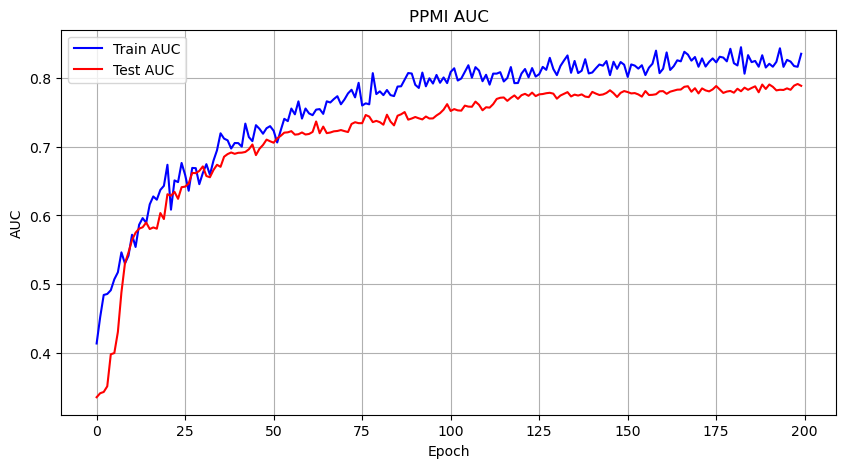

In [34]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(train_aucs)), train_aucs, label="Train AUC", color="blue")
plt.plot(range(len(test_aucs)), test_aucs, label="Test AUC", color="red")
plt.title("PPMI AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.grid(True)
plt.show()

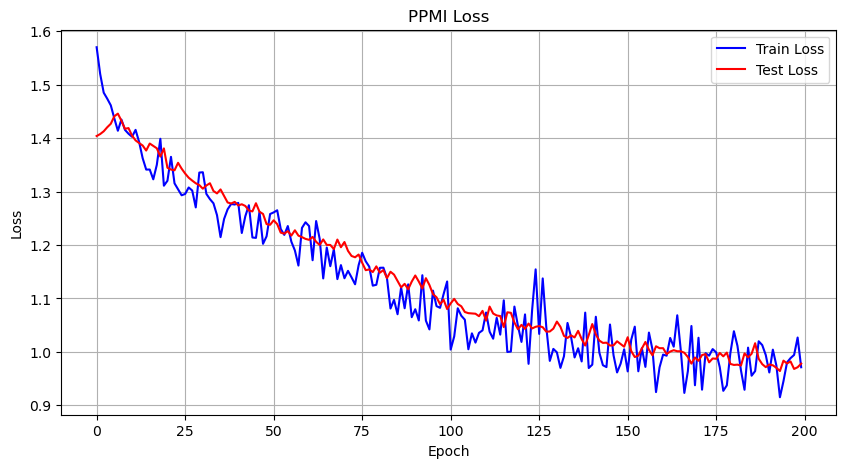

In [35]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(train_losses)), train_losses, label="Train Loss", color="blue")
plt.plot(range(len(test_losses)), test_losses, label="Test Loss", color="red")
plt.title("PPMI Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

Confusion Matrix (counts):
 [[19  0  4  1]
 [ 0 20  6  1]
 [ 3  0 10  1]
 [ 0 11  4  1]]

Classification Report:
              precision    recall  f1-score   support

          PD       0.86      0.79      0.83        24
     Control       0.65      0.74      0.69        27
       SWEDD       0.42      0.71      0.53        14
   Prodromal       0.25      0.06      0.10        16

    accuracy                           0.62        81
   macro avg       0.54      0.58      0.54        81
weighted avg       0.59      0.62      0.59        81



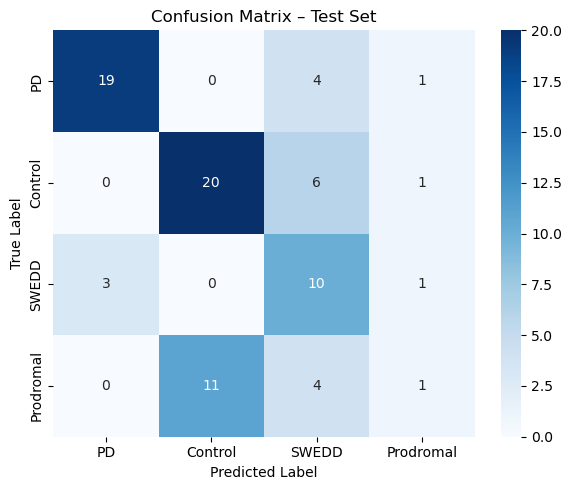

In [36]:
# ===== 计算并绘制测试集混淆矩阵 =====
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

model.eval()
all_preds   = []
all_labels  = []

with torch.no_grad():
    for inputs, kg_embed, labels in test_loader:
        inputs, kg_embed = inputs.to(device), kg_embed.to(device)
        outputs = model(inputs, kg_embed)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

# 1. 数值矩阵
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix (counts):\n", cm)

# 2. 文字报告（可选）
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=["PD", "Control", "SWEDD", "Prodromal"]))

# 3. 热力图可视化
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True, fmt="d", cmap="Blues",
    xticklabels=["PD", "Control", "SWEDD", "Prodromal"],
    yticklabels=["PD", "Control", "SWEDD", "Prodromal"]
)
plt.title("Confusion Matrix – Test Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


In [37]:
# === 模型算力 & 显存开销评估 ===
import time
import math
import torch

def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def _run_one_pass(model, batch, device, is_train=False, criterion=None):
    """
    兼容两种 DataLoader 输出：
    1. (inputs, labels)           —— 双模态 / 三模态无 k
    2. (inputs, kg_embed, labels) —— 三模态 + KG/DistMult/TransE
    """
    if isinstance(batch, (list, tuple)):
        if len(batch) == 2:
            x, y = batch
            x, y = x.to(device), y.to(device)
            inputs = (x,)
            labels = y.long()
        elif len(batch) == 3:
            x1, x2, y = batch
            x1, x2, y = x1.to(device), x2.to(device), y.to(device)
            inputs = (x1, x2)
            labels = y.long()
        else:
            raise ValueError(f"Unexpected batch structure, len={len(batch)}")
    else:
        raise ValueError(f"Unexpected batch type: {type(batch)}")

    if is_train:
        # 优先用你上面定义好的 criterion，没有就临时建一个
        if criterion is None:
            criterion_local = torch.nn.CrossEntropyLoss()
        else:
            criterion_local = criterion
    else:
        criterion_local = None

    start = time.perf_counter()
    if len(inputs) == 1:
        outputs = model(inputs[0])
    else:
        outputs = model(*inputs)

    if is_train and criterion_local is not None:
        loss = criterion_local(outputs, labels)
        # 不做 optimizer.step，只做 backward，模拟训练算力消耗
        model.zero_grad()
        loss.backward()

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    end = time.perf_counter()
    return end - start, labels.size(0)

def benchmark(model, loader, device, mode="inference", max_batches=10, criterion=None):
    """
    mode = "inference" 或 "train"
    max_batches 控制最多用多少个 batch 做采样，避免跑太久
    """
    use_cuda = torch.cuda.is_available()
    if use_cuda:
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats(device)

    model.to(device)
    is_train = (mode == "train")
    if is_train:
        model.train()
    else:
        model.eval()

    times = []
    total_samples = 0

    with torch.set_grad_enabled(is_train):
        for b_idx, batch in enumerate(loader):
            if b_idx >= max_batches:
                break
            t, n = _run_one_pass(model, batch, device,
                                 is_train=is_train, criterion=criterion)
            times.append(t)
            total_samples += n

    if not times:
        raise RuntimeError("benchmark loader is empty.")

    avg = sum(times) / len(times)
    var = sum((t - avg) ** 2 for t in times) / len(times)
    std = math.sqrt(var)
    batch_size = loader.batch_size if hasattr(loader, "batch_size") else int(round(total_samples / len(times)))
    peak_mem_mb = None
    if use_cuda:
        peak_mem_mb = torch.cuda.max_memory_allocated(device) / (1024 ** 2)

    return {
        "mode": mode,
        "batch_size": batch_size,
        "num_batches": len(times),
        "num_samples": total_samples,
        "avg_time_s_per_batch": avg,
        "std_time_s_per_batch": std,
        "avg_time_ms_per_sample": avg * 1000.0 * batch_size,
        "peak_mem_mb": peak_mem_mb,
    }

def run_full_profile(model, train_loader, test_loader, device, criterion=None, epochs_for_est=200):
    # 1. 参数量（大致权重内存）
    n_params = count_trainable_params(model)
    print(f"Model parameters: {n_params:,} (~{n_params * 4 / 1024 / 1024:.2f} MB FP32)")

    # 2. 推理阶段算力 & 显存
    print("\n=== Inference Microbenchmark ===")
    inf_stats = benchmark(
        model, test_loader, device,
        mode="inference", max_batches=10, criterion=None
    )
    for k, v in inf_stats.items():
        print(f"{k:>25}: {v}")

    # 3. 训练阶段算力（forward+backward，不更新参数） & 显存
    print("\n=== Training Microbenchmark (forward + backward, no optimizer.step) ===")
    train_stats = benchmark(
        model, train_loader, device,
        mode="train", max_batches=10, criterion=criterion
    )
    for k, v in train_stats.items():
        print(f"{k:>25}: {v}")

    # 4. 估算多 epoch 训练时间
    steps_per_epoch = len(train_loader)
    est_time_epoch = train_stats["avg_time_s_per_batch"] * steps_per_epoch
    print(f"\n=== 训练{epochs_for_est}轮算力评估 ===")
    print(f"训练批次数/轮: {steps_per_epoch}")
    print(f"估计单轮训练时间: {est_time_epoch:.3f}s (~{est_time_epoch/3600:.4f} h)")
    print(f"估计{epochs_for_est}轮训练时间: {est_time_epoch*epochs_for_est:.1f}s (~{est_time_epoch*epochs_for_est/3600:.4f} h)")

    # 5. 显存开销
    if inf_stats["peak_mem_mb"] is not None:
        print(f"\n推理阶段峰值显存占用: {inf_stats['peak_mem_mb']:.2f} MB")
        print(f"训练阶段峰值显存占用: {train_stats['peak_mem_mb']:.2f} MB")
    else:
        print("\n当前为 CPU 模式，无法统计 GPU 显存开销。")

# 直接调用一次，默认估计 200 epoch 的训练时间
# 注意：请确保上面已经执行过：
# - device = torch.device(...)
# - train_loader / test_loader / model / criterion 都已创建
run_full_profile(model, train_loader, test_loader, device, criterion, epochs_for_est=200)


Model parameters: 25,700 (~0.10 MB FP32)

=== Inference Microbenchmark ===
                     mode: inference
               batch_size: 32
              num_batches: 3
              num_samples: 81
     avg_time_s_per_batch: 0.00570409999969949
     std_time_s_per_batch: 0.0007223188263620464
   avg_time_ms_per_sample: 182.53119999038367
              peak_mem_mb: None

=== Training Microbenchmark (forward + backward, no optimizer.step) ===
                     mode: train
               batch_size: 32
              num_batches: 9
              num_samples: 258
     avg_time_s_per_batch: 0.015032711111214465
     std_time_s_per_batch: 0.0029777961491842422
   avg_time_ms_per_sample: 481.0467555588629
              peak_mem_mb: None

=== 训练200轮算力评估 ===
训练批次数/轮: 9
估计单轮训练时间: 0.135s (~0.0000 h)
估计200轮训练时间: 27.1s (~0.0075 h)

当前为 CPU 模式，无法统计 GPU 显存开销。
